# G1. Preprocessing and Data Exploration

**Authors:** Ivo Rambaldi and Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

## What this notebook does

It turns the raw Aequitas dataset into the train and test splits that every later notebook
reads, and it establishes the inequality that the rest of the project measures.

Input is stored in `Data/original.csv`, 83857 rows and 561 columns of questionnaire answers and test
scores from the Canary Islands school system. Output is `Data/train.csv`, `Data/test.csv` and
`Data/processed.csv`, plus the feature selection scores.

## The two prediction tasks

The raw data has no binary target. It has continuous scores, and we build two labels from
`score_MAT` by cutting it at a percentile computed on the training split only.

- `target_high_perf` is 1 for a student in the top quarter, the **excellence task**.
- `target_low_perf` is 1 for a student in the bottom quarter, the **underperformance task**.

The two labels are mutually exclusive: nobody is in both tails. We build both because Marrero
et al. (ECAI 2024) show that a model trained on circumstances is biased in opposite directions
depending on which tail it predicts, so looking only at the top quarter answers half the
question. Both thresholds and both column names come from the `tasks` block of `config.yaml`.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import check_prerequisites, get_logger, load_config, notebook_dirs
from src.utils.plotting import save_figure

logger = get_logger("G1")
check_prerequisites()

cfg = load_config(PROJECT_ROOT / "config" / "config.yaml")
RESULTS_DIR, FIGURES_DIR = notebook_dirs(cfg, "g1")

SEED = cfg["seed"]
SCORE_COL = cfg["target_score_column"]
PROTECTED = cfg["dataset"]["protected_attributes"]

print(f"seed          : {SEED}")
print(f"score column  : {SCORE_COL}")
print(f"protected     : {len(PROTECTED)} circumstances")
print(f"figures        : {FIGURES_DIR}")

Prerequisites: 16 satisfied, 0 missing, 0 mismatched.
seed          : 42
score column  : score_MAT
protected     : 13 circumstances
figures        : C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g1


## 2. Raw data

In [2]:
from src.data.loader import load_data
from src.data.preprocessor import nan_summary

raw = load_data(cfg["paths"]["raw_data"], download_url=cfg["paths"]["raw_data_url"])
print(f"Raw shape: {raw.shape[0]} rows, {raw.shape[1]} columns")

for prefix, block in [("a", "student"), ("d", "principal"), ("f", "family"), ("p", "teacher")]:
    n = sum(1 for c in raw.columns if c.startswith(prefix))
    print(f"  {prefix} ({block}): {n} columns")

Raw shape: 83857 rows, 561 columns
  a (student): 149 columns
  d (principal): 131 columns
  f (family): 81 columns
  p (teacher): 159 columns


### 2.1 Missingness in the raw data

Nearly half of all cells in this dataset are empty. That is not a data quality accident, it is
the subject matter: the dataset paper documents that the family questionnaire block is missing
not at random, because families in difficulty are the ones least likely to answer questions
about income, education and occupation.

552 of 561 columns have at least one missing value


Overall missing rate: 45.1%


2026-08-01 18:39:44 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g1\missingness_raw.png


WindowsPath('C:/Users/tomma/Desktop/petrellirambaldi2526/results/figures/g1/missingness_raw.png')

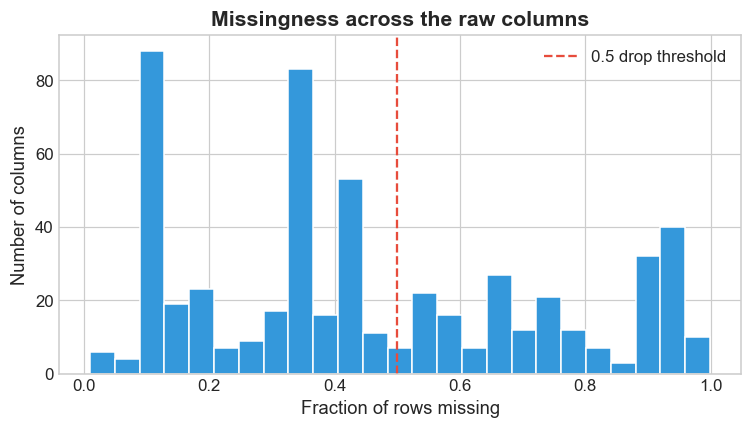

In [3]:
nan_raw = nan_summary(raw)
print(f"{len(nan_raw)} of {raw.shape[1]} columns have at least one missing value")
print(f"Overall missing rate: {raw.isna().to_numpy().mean():.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nan_raw["nan_fraction"], bins=25, color="#3498db", edgecolor="white")
ax.axvline(0.5, color="#e74c3c", ls="--", lw=1.5, label="0.5 drop threshold")
ax.set_xlabel("Fraction of rows missing")
ax.set_ylabel("Number of columns")
ax.set_title("Missingness across the raw columns")
ax.legend()
save_figure(fig, "missingness_raw", FIGURES_DIR)

## 3. Preprocessing

Here we:
- drop identifiers and availability flags,
- aggregate blocks of related questionnaire items into readable features,
- rename the survey codes,
- rescale the extent and frequency scales to the range 0 to 1,
- and drop any column missing in more than half the rows.

The one exception to that last rule is the protected attributes. A circumstance is never
dropped for being poorly answered, because how often it is answered is itself part of what we
are studying.

In [4]:
from src.data.preprocessor import preprocess

X, score, escs = preprocess(
    raw,
    target_col=SCORE_COL,
    nan_threshold=0.5,
    drop_other_scores=True,
    sensitive_cols=PROTECTED,
)
print(f"\nAfter preprocessing: {X.shape[0]} rows, {X.shape[1]} columns")
print(f"Protected attributes still present: {sum(c in X.columns for c in PROTECTED)} of {len(PROTECTED)}")

2026-08-01 18:39:44 | INFO     | src.data.preprocessor | Input shape: (83857, 561)


2026-08-01 18:39:44 | INFO     | src.data.preprocessor | structural drops


2026-08-01 18:39:44 | INFO     | src.data.preprocessor |   Dropping 8 identifier cols


2026-08-01 18:39:45 | INFO     | src.data.preprocessor |   Dropping 6 availability-flag cols


2026-08-01 18:39:45 | INFO     | src.data.preprocessor |   Dropping 28 redundant cols


...

2026-08-01 18:51:41 | INFO     | src.data.preprocessor |   Dropping 82 high-NaN cols


2026-08-01 18:51:42 | INFO     | src.data.preprocessor |   Dropping 5 score-leakage cols


2026-08-01 18:51:42 | INFO     | src.data.preprocessor |   Dropping 6971 rows with NaN target


2026-08-01 18:51:42 | INFO     | src.data.preprocessor | Done. X=(73152, 171)  target=score_MAT  ESCS NaN=19281



After preprocessing: 73152 rows, 171 columns
Protected attributes still present: 13 of 13


2026-08-01 18:51:42 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g1\missingness_protected.png


s_birth_country                                      78.4%
f_frequency_of_see_adult_read                        35.5%
f_father_occupation                                  34.8%
f_father_education_level                             32.8%
f_mother_occupation                                  30.7%
f_mother_education_level                             27.8%
f_start_schooling_age                                27.1%
f_ESCS                                               26.4%
f_extent_of_books_at_home                            25.9%
p_percentage_of_teachers_changed_school_last_year     6.2%
s_gender                                              0.7%
p_island                                              0.0%
p_public_or_private                                   0.0%


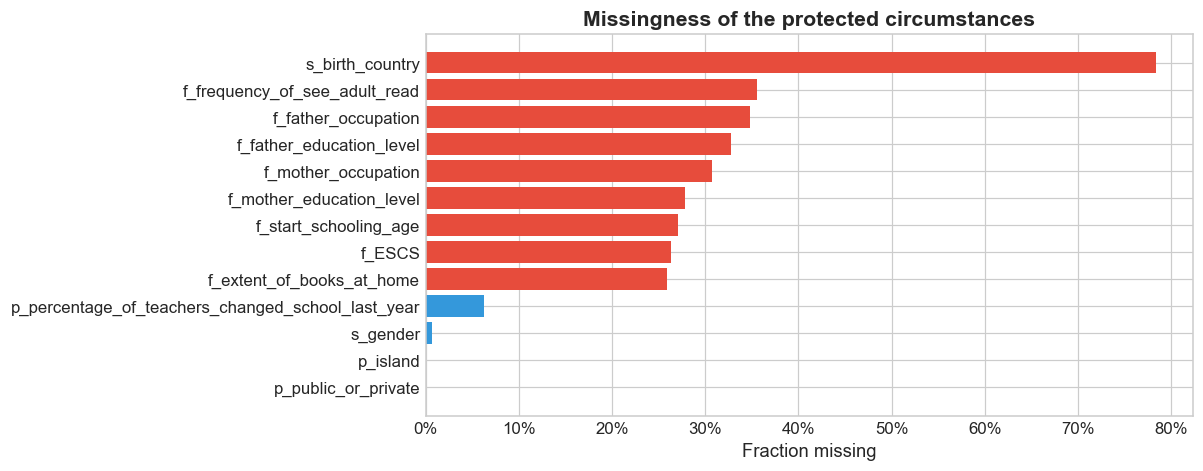

In [5]:
missing = X[[c for c in PROTECTED if c in X.columns]].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
colours = ["#e74c3c" if rate > 0.25 else "#3498db" for rate in missing]
ax.barh(missing.index[::-1], missing.values[::-1], color=colours[::-1])
ax.set_xlabel("Fraction missing")
ax.set_title("Missingness of the protected circumstances")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
save_figure(fig, "missingness_protected", FIGURES_DIR)

print(missing.apply(lambda v: f"{v:.1%}").to_string())

**Observation.** Missingness is concentrated in the family block and it is severe. Country of
birth is unanswered for most students and the parental education, occupation and ESCS columns
are unanswered for roughly a quarter to a third. The school level circumstances, which come
from administrative records rather than from a questionnaire, are almost complete.

## 4. Splitting and building the two targets

The split comes before anything is imputed. Fill values learned from the whole dataset would
carry information from the test rows into the training rows, so the split has to happen first
and the fill values have to be learned from the training side only.

In [6]:
from sklearn.model_selection import train_test_split

# Gender is missing for a small number of rows, so we drop them.
keep = X["s_gender"].notna()
print(f"Dropping {(~keep).sum()} rows with unknown gender, {keep.sum()} remain")
X, score = X[keep], score[keep]

X_train, X_test, score_train, score_test = train_test_split(
    X, score, test_size=0.2, random_state=SEED,
)
print(f"Train: {X_train.shape[0]} rows    Test: {X_test.shape[0]} rows")

Dropping 491 rows with unknown gender, 72661 remain
Train: 58128 rows    Test: 14533 rows


In [7]:
from src.data.preprocessor import build_percentile_target

targets_train, targets_test, thresholds = {}, {}, {}
for name, task in cfg["tasks"].items():
    y_tr, y_te, threshold = build_percentile_target(score_train, score_test, task)
    targets_train[task["column"]] = y_tr
    targets_test[task["column"]] = y_te
    thresholds[name] = threshold

overlap = (targets_train["target_high_perf"] & targets_train["target_low_perf"]).sum()
print(f"\nStudents in both tails: {overlap}")

2026-08-01 18:51:42 | INFO     | src.data.preprocessor | Target 'target_high_perf': upper tail at p75, threshold=569.009 from the training split only, positive rate train=25.0% test=24.4%


2026-08-01 18:51:42 | INFO     | src.data.preprocessor | Target 'target_low_perf': lower tail at p25, threshold=435.038 from the training split only, positive rate train=25.0% test=25.1%



Students in both tails: 0


2026-08-01 18:51:43 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g1\score_distribution_with_thresholds.png


WindowsPath('C:/Users/tomma/Desktop/petrellirambaldi2526/results/figures/g1/score_distribution_with_thresholds.png')

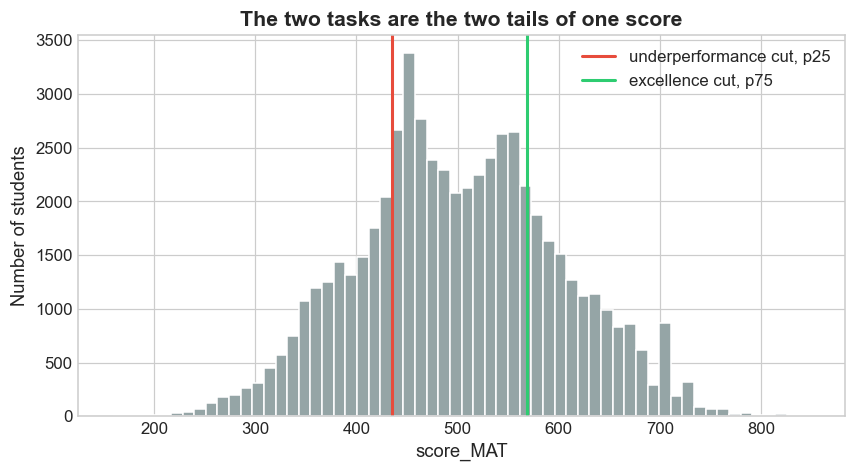

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(score_train.dropna(), bins=60, color="#95a5a6", edgecolor="white")
ax.axvline(thresholds["low_perf"], color="#e74c3c", lw=2,
           label=f"underperformance cut, p{cfg['tasks']['low_perf']['percentile']}")
ax.axvline(thresholds["high_perf"], color="#2ecc71", lw=2,
           label=f"excellence cut, p{cfg['tasks']['high_perf']['percentile']}")
ax.set_xlabel(SCORE_COL)
ax.set_ylabel("Number of students")
ax.set_title("The two tasks are the two tails of one score")
ax.legend()
save_figure(fig, "score_distribution_with_thresholds", FIGURES_DIR)

## 5. Imputation

Ordinary columns are filled, with the median for continuous ones, the mode for short integer
scales and an explicit `UNKNOWN` category for text ones. The fill values are computed on the
training split and then applied unchanged to the test split.

Protected attributes are never filled. Instead each one gets a companion `{attribute}_was_nan`
column recording that the answer was absent. Imputing a circumstance would invent group
membership for the students whose group we do not know, and those students are not a random
sample: they are disproportionately the ones the questionnaire failed to reach. Filling them in
would quietly move them into whichever group is most common, which is exactly the population
whose treatment we are trying to measure.

In [9]:
from src.data.imputation import apply_imputation, fit_imputation, imputation_report

plan = fit_imputation(X_train, sensitive_cols=PROTECTED)

X_train_filled, flags_train = apply_imputation(X_train, plan)
X_test_filled, flags_test = apply_imputation(X_test, plan)

report = imputation_report(X_train, X_train_filled, plan)
print(f"\nColumns handled: {len(report)}")
print(report["strategy"].value_counts().to_string())

2026-08-01 18:51:43 | INFO     | src.data.imputation | Imputation plan fitted on the training split: 157 columns filled, 10 protected attributes flagged instead



Columns handled: 167
strategy
mode       80
median     65
unknown    12
flag       10


2026-08-01 18:51:44 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g1\imputation_strategies.png


WindowsPath('C:/Users/tomma/Desktop/petrellirambaldi2526/results/figures/g1/imputation_strategies.png')

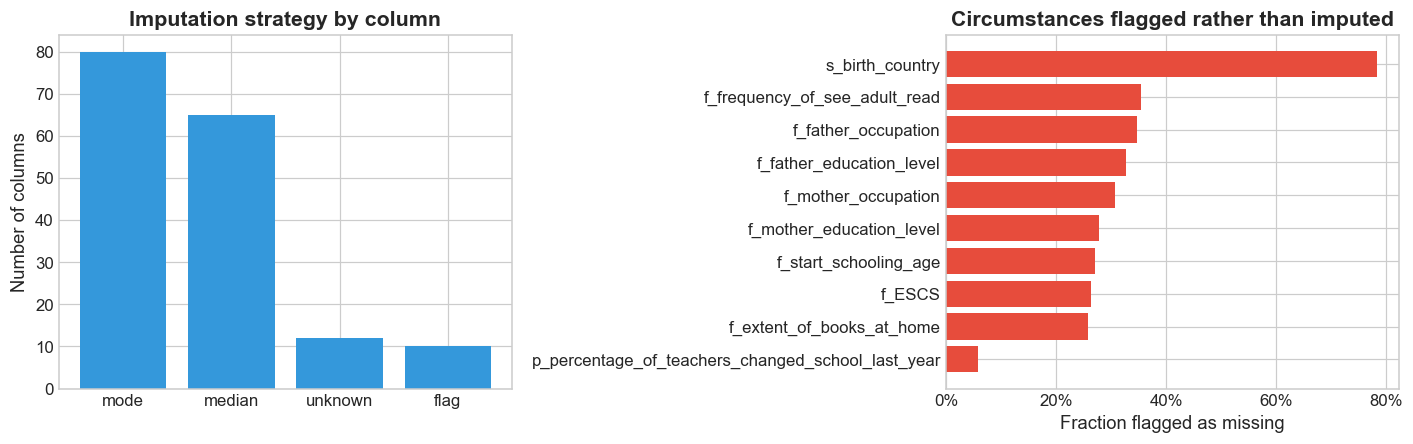

In [10]:
strategies = report["strategy"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(strategies.index, strategies.values, color="#3498db")
axes[0].set_ylabel("Number of columns")
axes[0].set_title("Imputation strategy by column")

flag_rates = flags_train.mean().sort_values()
axes[1].barh([c.replace("_was_nan", "") for c in flag_rates.index], flag_rates.values, color="#e74c3c")
axes[1].set_xlabel("Fraction flagged as missing")
axes[1].set_title("Circumstances flagged rather than imputed")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

fig.tight_layout()
save_figure(fig, "imputation_strategies", FIGURES_DIR)

2026-08-01 18:51:45 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g1\missingness_correlation.png


WindowsPath('C:/Users/tomma/Desktop/petrellirambaldi2526/results/figures/g1/missingness_correlation.png')

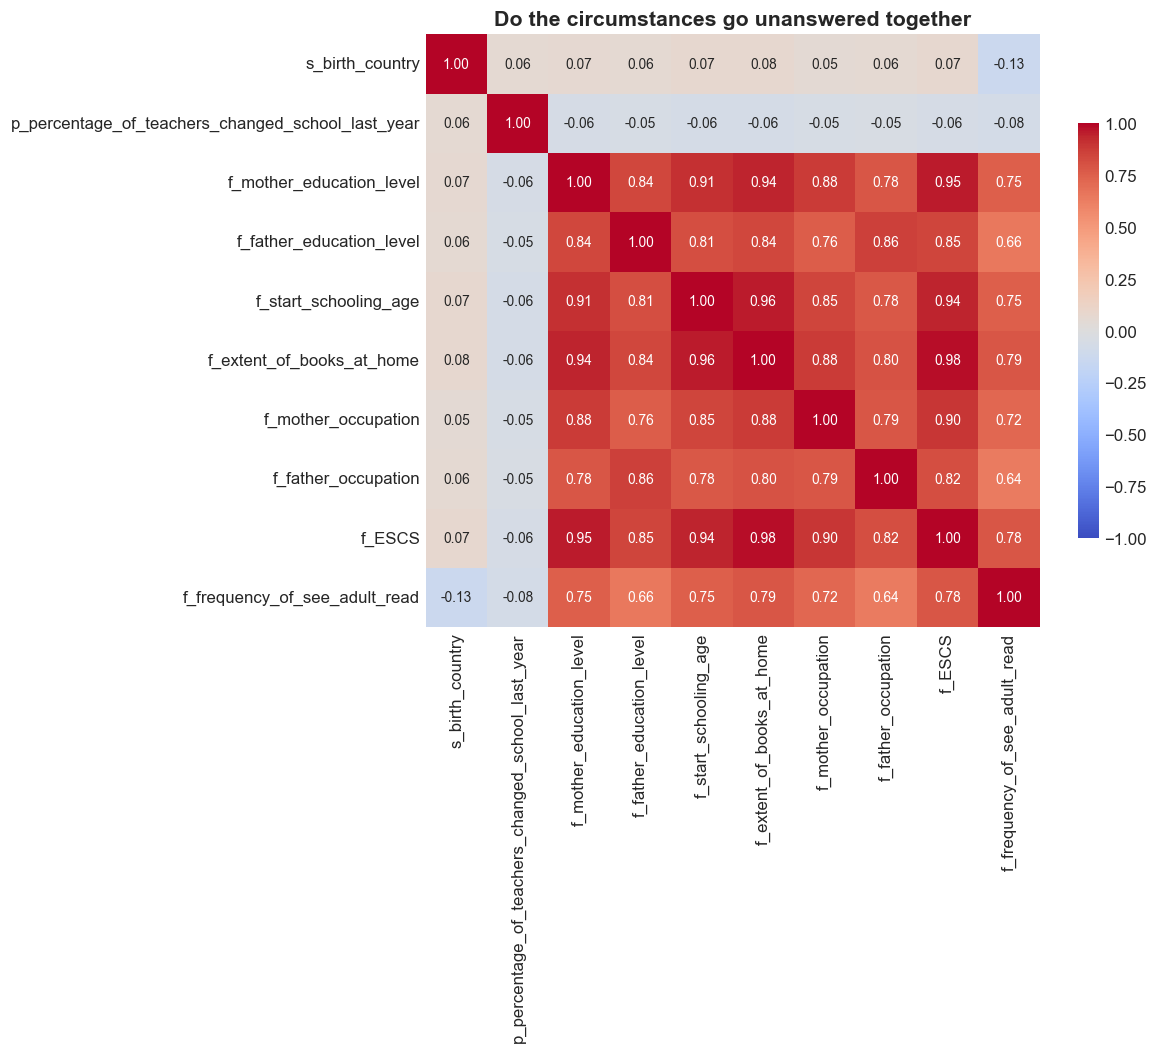

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
labels = [c.replace("_was_nan", "") for c in flags_train.columns]
sns.heatmap(flags_train.astype(int).corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 9}, cbar_kws={"shrink": 0.7})
ax.set_title("Do the circumstances go unanswered together")
save_figure(fig, "missingness_correlation", FIGURES_DIR)

**Observation.** The family block items are missing together almost perfectly, which says a
household either answered the family questionnaire or did not. Missingness is therefore a
property of the household, not of the individual question, and treating it as a random gap per
column would be wrong. The school level circumstance is uncorrelated with the family block, as
expected for a different data source.

## 6. Feature selection

`preprocess()` leaves a large number of raw questionnaire items that no aggregation rule
covered. They add dimensionality without adding much signal, which hurts the deep generative
models in synthetic data generation section in particular.

We score every non-sensitive column by mutual information with the target and keep the top 25.
Every protected attribute is kept regardless of its score, because fairness auditing needs them
whether or not they predict well.

One selection is used for both tasks. Marrero et al. run the same predictors over three slices
of the outcome distribution, and holding the feature set fixed is exactly what isolates the
effect of the task rather than confounding it with a change of inputs. The selection is scored
against the excellence target; that asymmetry is a property of the ranking step, not of the
design, and it is the reason the same set is used rather than a per task one.

In [12]:
from src.data.feature_selection import select_features

selected, scores = select_features(
    X_train_filled, targets_train["target_high_perf"], PROTECTED, cfg,
)
scores.to_csv(RESULTS_DIR / "feature_selection_scores.csv", index=False)

X_train_filled = X_train_filled[selected]
X_test_filled = X_test_filled[selected]

kept_protected = [c for c in PROTECTED if c in selected]
print(f"Kept {len(selected)} columns: {len(kept_protected)} circumstances and "
      f"{len(selected) - len(kept_protected)} selected features")
print(f"\nTop 10 by mutual information:")
print(scores.head(10).to_string(index=False))

2026-08-01 18:52:29 | INFO     | src.data.feature_selection | Feature selection (mutual_info): kept 25/158 non-sensitive candidates + 13/13 protected attrs -> 38 total columns.


Kept 38 columns: 13 circumstances and 25 selected features

Top 10 by mutual information:
                        column    score  selected
                          d9a1 0.024629      True
                          d9c1 0.024463      True
                          d9b1 0.022679      True
                         d16an 0.015538      True
                         d16bn 0.014270      True
                           a3a 0.012569      True
                  s_birth_year 0.011710      True
                            a5 0.011256      True
                          d9d1 0.011177      True
f_frequency_of_support_at_home 0.011054      True


## 7. The inequality this project measures

Before any model is trained, the circumstances already predict the score. Everything G3 and G4
report about fairness is a measurement of how synthetic data interacts with the inequality
shown here, not of inequality that the pipeline introduces.

2026-08-01 18:52:29 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g1\escs_by_score_quartile.png


             mean  count
quartile                
Q1 lowest  -0.313   9857
Q2         -0.083  10514
Q3          0.112  11044
Q4 highest  0.370  11417


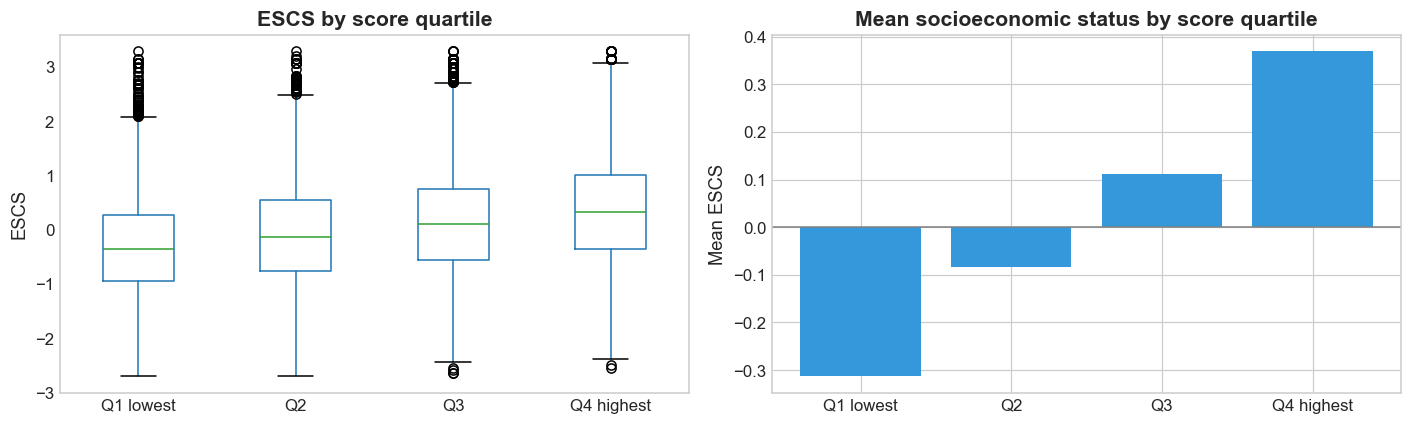

In [13]:
quartile = pd.qcut(score_train, q=4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
escs_train = X_train["f_ESCS"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

grouped = pd.DataFrame({"escs": escs_train, "quartile": quartile}).dropna()
grouped.boxplot(column="escs", by="quartile", ax=axes[0], grid=False)
axes[0].set_title("ESCS by score quartile")
axes[0].set_xlabel("")
axes[0].set_ylabel("ESCS")
fig.suptitle("")

means = grouped.groupby("quartile", observed=True)["escs"].mean()
axes[1].bar(means.index.astype(str), means.values, color="#3498db")
axes[1].axhline(0, color="grey", lw=1)
axes[1].set_ylabel("Mean ESCS")
axes[1].set_title("Mean socioeconomic status by score quartile")

fig.tight_layout()
save_figure(fig, "escs_by_score_quartile", FIGURES_DIR)

print(grouped.groupby("quartile", observed=True)["escs"].agg(["mean", "count"]).round(3).to_string())

2026-08-01 18:52:30 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g1\protected_vs_score.png


WindowsPath('C:/Users/tomma/Desktop/petrellirambaldi2526/results/figures/g1/protected_vs_score.png')

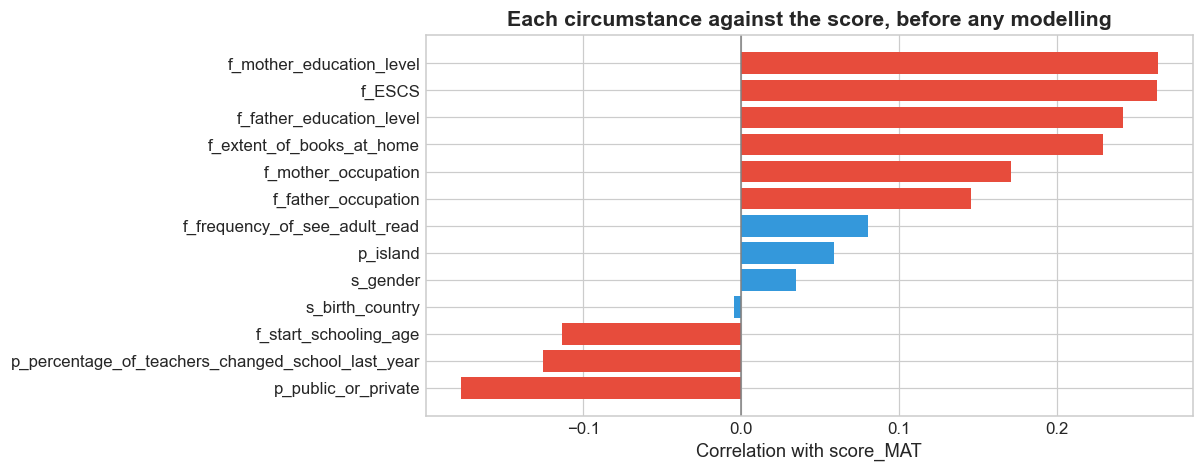

In [14]:
from sklearn.preprocessing import OrdinalEncoder

present = [c for c in PROTECTED if c in X_train.columns]
encoded = X_train[present].copy()
text_cols = encoded.select_dtypes(include="object").columns.tolist()
if text_cols:
    encoded[text_cols] = OrdinalEncoder(
        handle_unknown="use_encoded_value", unknown_value=-1
    ).fit_transform(encoded[text_cols].astype(str))

correlation = encoded.apply(pd.to_numeric, errors="coerce").corrwith(score_train).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
colours = ["#e74c3c" if abs(v) > 0.1 else "#3498db" for v in correlation]
ax.barh(correlation.index, correlation.values, color=colours)
ax.axvline(0, color="grey", lw=1)
ax.set_xlabel(f"Correlation with {SCORE_COL}")
ax.set_title("Each circumstance against the score, before any modelling")
save_figure(fig, "protected_vs_score", FIGURES_DIR)

**Observation.** Mean socioeconomic status rises monotonically from the bottom score quartile to
the top, and the family circumstances correlate with the score directly. Parental education,
parental occupation, books at home and ESCS are the strongest; gender and the school level
circumstances are weak by comparison. This ordering matches the relative importance Marrero et
al. report for the same circumstances.

Two consequences:
1. Any classifier trained on these features will reproduce this pattern, so an unfair result in G3 is inherited rather than created.
2. Because the strongest circumstances are also the ones with the heaviest missingness, the students we know least about are concentrated at the disadvantaged end.

## 8. Saving the splits

In [15]:
from src.data.persistence import save_csv

train_df = pd.concat([X_train_filled, flags_train, pd.DataFrame(targets_train)], axis=1)
test_df = pd.concat([X_test_filled, flags_test, pd.DataFrame(targets_test)], axis=1)

save_csv(train_df, cfg["paths"]["train_data"])
save_csv(test_df, cfg["paths"]["test_data"])
save_csv(pd.concat([train_df, test_df], axis=0, ignore_index=True), cfg["paths"]["processed_data"])

print(f"train {train_df.shape}    test {test_df.shape}")
for column in [task["column"] for task in cfg["tasks"].values()]:
    print(f"  {column}: train {train_df[column].mean():.1%} positive, "
          f"test {test_df[column].mean():.1%} positive")

2026-08-01 18:52:32 | INFO     | src.data.persistence | Saved 58128 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\Data\train.csv


2026-08-01 18:52:32 | INFO     | src.data.persistence | Saved 14533 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\Data\test.csv


2026-08-01 18:52:35 | INFO     | src.data.persistence | Saved 72661 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\Data\processed.csv


train (58128, 50)    test (14533, 50)
  target_high_perf: train 25.0% positive, test 24.4% positive
  target_low_perf: train 25.0% positive, test 25.1% positive


## 9. Final observations

- Missingness in the family block is systematic and correlated within a household, so the
  circumstances are flagged rather than imputed and the flags are excluded from the feature
  set used for modelling.
- The socioeconomic gradient across score quartiles is clear and monotone. This is the
  pre-existing inequality that G3 measures and G4 attempts to mitigate.
- The two targets are built from one score and are mutually exclusive, so both travel together
  through generation in G2 and only the evaluation target changes between a notebook and its
  underperformance twin.
- One feature set serves both tasks, so any difference between the excellence and the
  underperformance results comes from the task and not from the inputs.